
[INFO] Memproses Indonesia (Format .npy murni)...
  -> SUKSES! 500 matriks.

[INFO] Memproses STEAD Global dari Extreme SSD...
  -> SUKSES! 500 matriks.

[INFO] Memproses UUSS (Isolasi Data Tak Terdaftar)...
  -> Ditemukan 0 ID tak terdaftar di CSV (Asumsi: murni Noise).
  -> SUKSES! 0 matriks.

[INFO] Mengkalkulasi Power Spectral Density (Metode Welch)...

[INFO] Merender Grafik Komparasi Forensik...


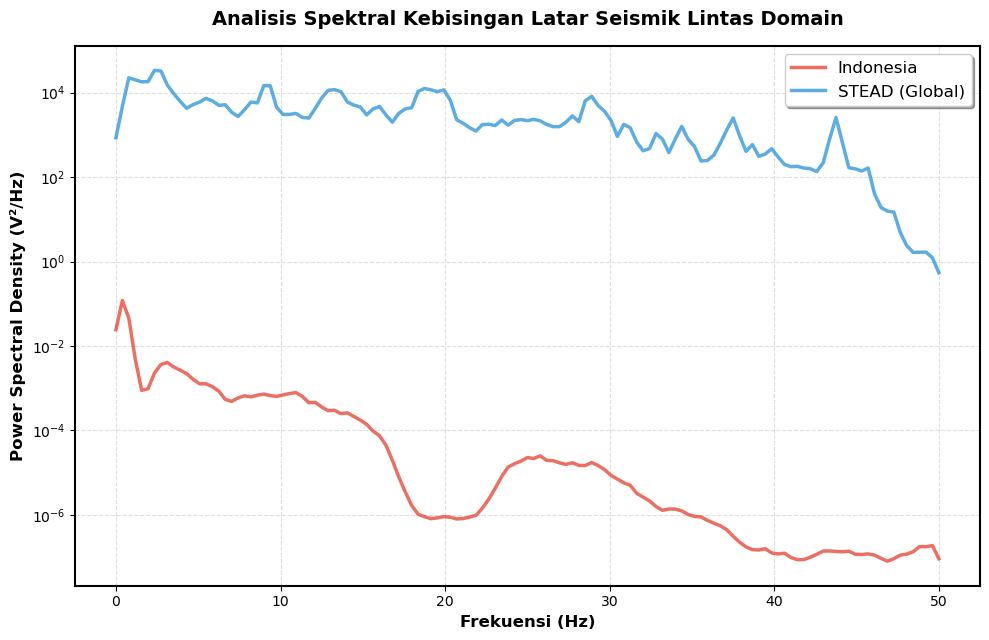


[SELESAI] Grafik bukti empiris 3-Domain berhasil ditampilkan di layar.


In [5]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_UUSS_META = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C meta, test snr_db, n2222.csv'

N_SAMPLES = 500  
FS = 100         

if __name__ == "__main__":
    noise_collection = {}

    # 1. EKSTRAKSI INDONESIA (.npy)
    print("\n[INFO] Memproses Indonesia (Format .npy murni)...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['Indonesia'] = np.array([np.load(f)[:700] for f in selected_npy])
    print(f"  -> SUKSES! {len(noise_collection['Indonesia'])} matriks.")

    # 2. EKSTRAKSI STEAD DARI EXTREME SSD
    print("\n[INFO] Memproses STEAD Global dari Extreme SSD...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_waves = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_waves.append(f_h5['data'][trace][()][:700])
    noise_collection['STEAD (Global)'] = np.array(stead_waves)
    print(f"  -> SUKSES! {len(stead_waves)} matriks.")
    del df_stead, df_stead_noise

    # 3. EKSTRAKSI UUSS (MENGGUNAKAN LOGIKA "UNLISTED IDs")
    print("\n[INFO] Memproses UUSS (Isolasi Data Tak Terdaftar)...")
    df_uuss = pd.read_csv(PATH_UUSS_META, header=None)
    gempa_ids = set(df_uuss[0].astype(str).str.strip().tolist())
    
    with open(PATH_UUSS_JSON, 'r') as f:
        uuss_data = json.load(f)
    
    noise_keys = [k for k in uuss_data.keys() if str(k).strip() not in gempa_ids]
    print(f"  -> Ditemukan {len(noise_keys)} ID tak terdaftar di CSV (Asumsi: murni Noise).")
    
    np.random.seed(42)
    selected_uuss_keys = np.random.choice(noise_keys, min(N_SAMPLES, len(noise_keys)), replace=False)
    
    uuss_waves = [np.array(uuss_data[k])[:700] for k in selected_uuss_keys]
    noise_collection['UUSS (Utah, Latih Asli)'] = np.array(uuss_waves)
    print(f"  -> SUKSES! {len(uuss_waves)} matriks.")

    # ==========================================================================
    # KALKULASI PSD & VISUALISASI
    # ==========================================================================
    print("\n[INFO] Mengkalkulasi Power Spectral Density (Metode Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        all_psd = []
        for wave in waves:
            z_component = wave[:, -1] if len(wave.shape) > 1 and wave.shape[-1] == 3 else wave.flatten()
            z_component = z_component - np.mean(z_component)
            freqs, psd = welch(z_component, fs=FS, nperseg=256)
            all_psd.append(psd)
        psd_results[domain] = (freqs, np.mean(all_psd, axis=0))

    print("\n[INFO] Merender Grafik Komparasi Forensik...")
    plt.figure(figsize=(10, 6.5))
    colors = {'Indonesia': '#e74c3c', 'STEAD (Global)': '#3498db', 'UUSS (Utah, Latih Asli)': '#2ecc71'}
    
    for domain, (freqs, mean_psd) in psd_results.items():
        plt.semilogy(freqs, mean_psd, label=domain, color=colors.get(domain, 'black'), linewidth=2.5, alpha=0.8)

    plt.title("Analisis Spektral Kebisingan Latar Seismik Lintas Domain", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (V²/Hz)", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(fontsize=12, frameon=True, shadow=True)
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    
    # MENAMPILKAN GRAFIK LANGSUNG KE LAYAR
    plt.show()
    print("\n[SELESAI] Grafik bukti empiris 3-Domain berhasil ditampilkan di layar.")

In [6]:
# -*- coding: utf-8 -*-
import json
import pandas as pd
import numpy as np

# Path absolut ke file
PATH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'
PATH_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv'

if __name__ == "__main__":
    print("="*60)
    print(" 🕵️ PEMBEDAHAN FILE JSON (DATA GELOMBANG)")
    print("="*60)
    try:
        with open(PATH_JSON, 'r') as f:
            stead_json = json.load(f)
            
        total_keys = len(stead_json.keys())
        print(f"[INFO] Total Trace ID di dalam JSON : {total_keys} matriks")
        
        # Mengintip 1 sampel data pertama
        first_key = list(stead_json.keys())[0]
        first_matrix = np.array(stead_json[first_key])
        print(f"[INFO] Contoh Trace ID (Kunci)      : {first_key}")
        print(f"[INFO] Bentuk Matriks (Shape)       : {first_matrix.shape}")
        print(f"[INFO] Tipe Data dalam Matriks      : {first_matrix.dtype}")
    except Exception as e:
        print(f"[ERROR] Gagal membedah JSON: {e}")

    print("\n" + "="*60)
    print(" 📊 PEMBEDAHAN FILE CSV (METADATA & LABEL)")
    print("="*60)
    try:
        df_meta = pd.read_csv(PATH_CSV)
        
        print(f"[INFO] Total Baris Data di CSV      : {len(df_meta)} baris")
        print(f"[INFO] Total Kolom (Atribut)        : {len(df_meta.columns)} kolom\n")
        
        print(" DAFTAR LENGKAP KOLOM:")
        for i, col in enumerate(df_meta.columns):
            print(f"  {i+1}. {col}")
            
        print("\n" + "-"*60)
        # Analisis khusus pada kolom label utama
        label_col = 'trace_category'
        if label_col in df_meta.columns:
            print(f" RINCIAN LABEL PADA KOLOM '{label_col}':")
            label_counts = df_meta[label_col].value_counts()
            for label, count in label_counts.items():
                print(f"  -> '{label}': {count} sampel")
        else:
            print(f" [WARNING] Kolom '{label_col}' tidak ditemukan.")
            
    except Exception as e:
        print(f"[ERROR] Gagal membedah CSV: {e}")
    print("="*60)

 🕵️ PEMBEDAHAN FILE JSON (DATA GELOMBANG)
[INFO] Total Trace ID di dalam JSON : 15275 matriks
[INFO] Contoh Trace ID (Kunci)      : 1127269
[INFO] Bentuk Matriks (Shape)       : ()
[INFO] Tipe Data dalam Matriks      : object

 📊 PEMBEDAHAN FILE CSV (METADATA & LABEL)
[INFO] Total Baris Data di CSV      : 15275 baris
[INFO] Total Kolom (Atribut)        : 37 kolom

 DAFTAR LENGKAP KOLOM:
  1. index_o
  2. network_code
  3. receiver_code
  4. receiver_type
  5. receiver_latitude
  6. receiver_longitude
  7. receiver_elevation_m
  8. p_arrival_sample
  9. p_status
  10. p_weight
  11. p_travel_sec
  12. s_arrival_sample
  13. s_status
  14. s_weight
  15. source_id
  16. source_origin_time
  17. source_origin_uncertainty_sec
  18. source_latitude
  19. source_longitude
  20. source_error_sec
  21. source_gap_deg
  22. source_horizontal_uncertainty_km
  23. source_depth_km
  24. source_depth_uncertainty_km
  25. source_magnitude
  26. source_magnitude_type
  27. source_magnitude_author
  2


[INFO] Mengekstraksi Ambient Noise Indonesia...
[INFO] Mengekstraksi Ambient Noise STEAD Global...
[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...
[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...

[INFO] Mengkalkulasi Power Spectral Density (Welch)...
[INFO] Merender Grafik Investigasi Final...


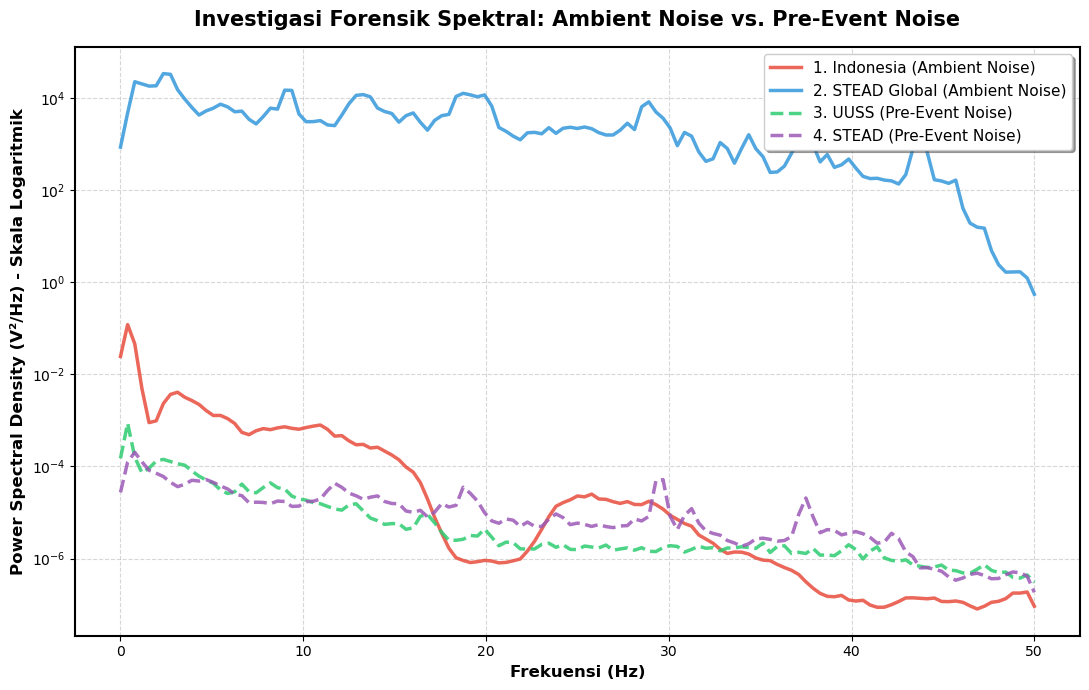


[SELESAI] Grafik investigasi final berhasil ditampilkan di layar.


In [7]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
# 1. Ambient Noise Murni
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

# 2. Pre-Event Noise (Dari JSON Evaluasi Baseline)
PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 500  
FS = 100         

if __name__ == "__main__":
    noise_collection = {}

    # --------------------------------------------------------------------------
    # 1. EKSTRAKSI AMBIENT NOISE MURNI (Stress Test Bapak)
    # --------------------------------------------------------------------------
    print("\n[INFO] Mengekstraksi Ambient Noise Indonesia...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['1. Indonesia (Ambient Noise)'] = np.array([np.load(f)[:700, -1] for f in selected_npy])

    print("[INFO] Mengekstraksi Ambient Noise STEAD Global...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_ambient = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_ambient.append(f_h5['data'][trace][()][:700, -1])
    noise_collection['2. STEAD Global (Ambient Noise)'] = np.array(stead_ambient)
    del df_stead, df_stead_noise

    # --------------------------------------------------------------------------
    # 2. EKSTRAKSI PRE-EVENT NOISE (Cara Evaluasi Zhi Geng)
    # --------------------------------------------------------------------------
    print("[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...")
    with open(PATH_UUSS_JSON, 'r') as f:
        uuss_data = json.load(f)
    
    uuss_keys = list(uuss_data.keys())
    np.random.seed(42)
    sel_uuss_keys = np.random.choice(uuss_keys, min(N_SAMPLES, len(uuss_keys)), replace=False)
    
    # Ambil kunci "Z_noise" dan pastikan panjangnya 700
    uuss_pre_noise = [np.array(uuss_data[k]["Z_noise"])[-700:] for k in sel_uuss_keys if "Z_noise" in uuss_data[k]]
    noise_collection['3. UUSS (Pre-Event Noise)'] = np.array(uuss_pre_noise)

    print("[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...")
    with open(PATH_STEAD_BENCH_JSON, 'r') as f:
        stead_bench_data = json.load(f)
        
    stead_bench_keys = list(stead_bench_data.keys())
    np.random.seed(42)
    sel_stead_bench = np.random.choice(stead_bench_keys, min(N_SAMPLES, len(stead_bench_keys)), replace=False)
    
    stead_pre_noise = [np.array(stead_bench_data[k]["Z_noise"])[-700:] for k in sel_stead_bench if "Z_noise" in stead_bench_data[k]]
    noise_collection['4. STEAD (Pre-Event Noise)'] = np.array(stead_pre_noise)

    # --------------------------------------------------------------------------
    # 3. KALKULASI PSD & VISUALISASI LENGKAP
    # --------------------------------------------------------------------------
    print("\n[INFO] Mengkalkulasi Power Spectral Density (Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        all_psd = []
        for wave in waves:
            # Sinyal sudah diekstrak komponen Z saja
            wave = wave - np.mean(wave) # Detrending
            freqs, psd = welch(wave, fs=FS, nperseg=256)
            all_psd.append(psd)
        psd_results[domain] = (freqs, np.mean(all_psd, axis=0))

    print("[INFO] Merender Grafik Investigasi Final...")
    plt.figure(figsize=(11, 7))
    
    colors = {
        '1. Indonesia (Ambient Noise)': '#e74c3c',       # Merah 
        '2. STEAD Global (Ambient Noise)': '#3498db',    # Biru
        '3. UUSS (Pre-Event Noise)': '#2ecc71',          # Hijau
        '4. STEAD (Pre-Event Noise)': '#9b59b6'          # Ungu
    }
    
    linestyles = {
        '1. Indonesia (Ambient Noise)': '-',       
        '2. STEAD Global (Ambient Noise)': '-',    
        '3. UUSS (Pre-Event Noise)': '--',          # Garis putus-putus untuk Pre-Event
        '4. STEAD (Pre-Event Noise)': '--'          
    }
    
    for domain, (freqs, mean_psd) in sorted(psd_results.items()):
        plt.semilogy(freqs, mean_psd, label=domain, 
                     color=colors.get(domain, 'black'), 
                     linestyle=linestyles.get(domain, '-'),
                     linewidth=2.5, alpha=0.85)

    plt.title("Investigasi Forensik Spektral: Ambient Noise vs. Pre-Event Noise", fontsize=15, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (V²/Hz) - Skala Logaritmik", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11, frameon=True, shadow=True, loc='upper right')
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    plt.show()
    print("\n[SELESAI] Grafik investigasi final berhasil ditampilkan di layar.")


[INFO] Mengekstraksi Ambient Noise Indonesia...
[INFO] Mengekstraksi Ambient Noise STEAD Global...
[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...
[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...

[INFO] MENERAPKAN MAX-ABSOLUTE NORMALIZATION (Standar Zhi Geng)...
[INFO] Mengkalkulasi Power Spectral Density (Welch)...
[INFO] Merender Grafik Bukti Paradoks Normalisasi...


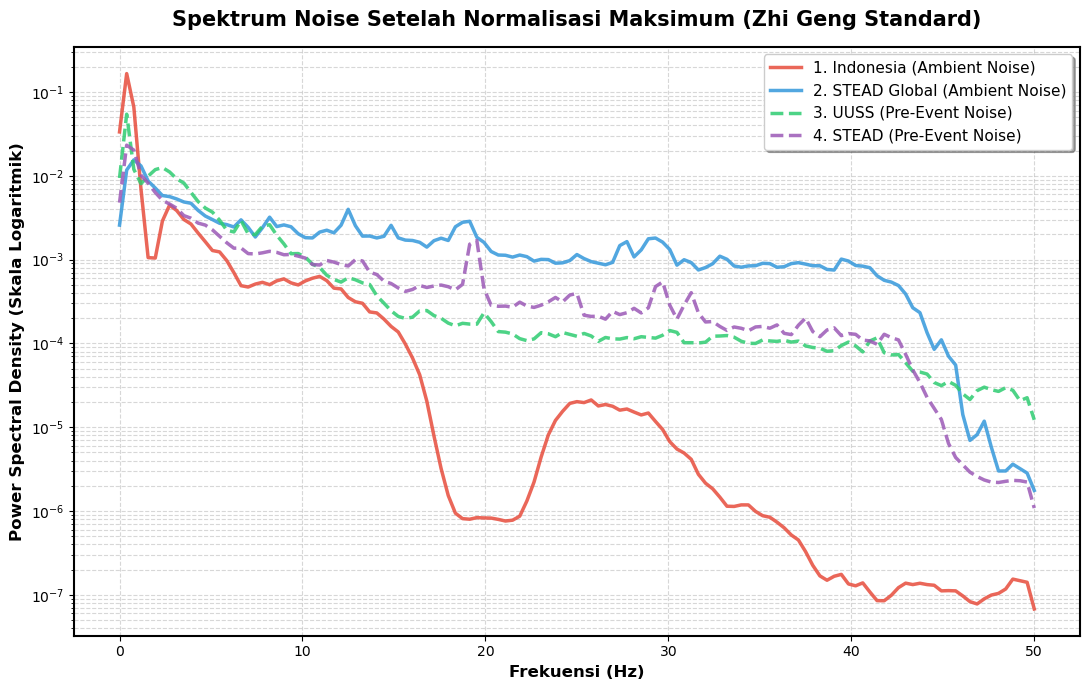


[SELESAI] Grafik efek normalisasi berhasil ditampilkan di layar.


In [8]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 500  
FS = 100         

# ==============================================================================
# FUNGSI PRAPEMROSESAN STANDAR ZHI GENG (BASELINE)
# ==============================================================================
def zhi_geng_standard_preprocessing(wave):
    """
    Meniru 100% perlakuan model baseline terhadap sinyal:
    1. Detrending (dikurangi mean)
    2. Max-Absolute Normalization (puncak ditarik ke 1.0)
    """
    wave = wave - np.mean(wave) # Detrending
    max_val = np.max(np.abs(wave))
    if max_val > 0:
        wave = wave / max_val   # Normalisasi ekstrem
    return wave

if __name__ == "__main__":
    noise_collection = {}

    # 1. EKSTRAKSI AMBIENT NOISE MURNI
    print("\n[INFO] Mengekstraksi Ambient Noise Indonesia...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['1. Indonesia (Ambient Noise)'] = np.array([np.load(f)[:700, -1] for f in selected_npy])

    print("[INFO] Mengekstraksi Ambient Noise STEAD Global...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_ambient = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_ambient.append(f_h5['data'][trace][()][:700, -1])
    noise_collection['2. STEAD Global (Ambient Noise)'] = np.array(stead_ambient)
    del df_stead, df_stead_noise

    # 2. EKSTRAKSI PRE-EVENT NOISE
    print("[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...")
    with open(PATH_UUSS_JSON, 'r') as f: uuss_data = json.load(f)
    uuss_keys = list(uuss_data.keys())
    np.random.seed(42)
    sel_uuss_keys = np.random.choice(uuss_keys, min(N_SAMPLES, len(uuss_keys)), replace=False)
    noise_collection['3. UUSS (Pre-Event Noise)'] = np.array([np.array(uuss_data[k]["Z_noise"])[-700:] for k in sel_uuss_keys if "Z_noise" in uuss_data[k]])

    print("[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...")
    with open(PATH_STEAD_BENCH_JSON, 'r') as f: stead_bench_data = json.load(f)
    stead_bench_keys = list(stead_bench_data.keys())
    np.random.seed(42)
    sel_stead_bench = np.random.choice(stead_bench_keys, min(N_SAMPLES, len(stead_bench_keys)), replace=False)
    noise_collection['4. STEAD (Pre-Event Noise)'] = np.array([np.array(stead_bench_data[k]["Z_noise"])[-700:] for k in sel_stead_bench if "Z_noise" in stead_bench_data[k]])

    # 3. IMPLEMENTASI STANDAR ZHI GENG & KALKULASI PSD
    print("\n[INFO] MENERAPKAN MAX-ABSOLUTE NORMALIZATION (Standar Zhi Geng)...")
    print("[INFO] Mengkalkulasi Power Spectral Density (Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        all_psd = []
        for wave in waves:
            # ---> KUNCI UTAMA: Terapkan normalisasi sebelum spektral <---
            processed_wave = zhi_geng_standard_preprocessing(wave)
            
            freqs, psd = welch(processed_wave, fs=FS, nperseg=256)
            all_psd.append(psd)
        psd_results[domain] = (freqs, np.mean(all_psd, axis=0))

    # 4. VISUALISASI
    print("[INFO] Merender Grafik Bukti Paradoks Normalisasi...")
    plt.figure(figsize=(11, 7))
    
    colors = {'1. Indonesia (Ambient Noise)': '#e74c3c', '2. STEAD Global (Ambient Noise)': '#3498db', 
              '3. UUSS (Pre-Event Noise)': '#2ecc71', '4. STEAD (Pre-Event Noise)': '#9b59b6'}
    linestyles = {'1. Indonesia (Ambient Noise)': '-', '2. STEAD Global (Ambient Noise)': '-', 
                  '3. UUSS (Pre-Event Noise)': '--', '4. STEAD (Pre-Event Noise)': '--'}
    
    for domain, (freqs, mean_psd) in sorted(psd_results.items()):
        plt.semilogy(freqs, mean_psd, label=domain, color=colors.get(domain, 'black'), 
                     linestyle=linestyles.get(domain, '-'), linewidth=2.5, alpha=0.85)

    plt.title("Spektrum Noise Setelah Normalisasi Maksimum (Zhi Geng Standard)", fontsize=15, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (Skala Logaritmik)", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11, frameon=True, shadow=True, loc='upper right')
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    plt.show()
    print("\n[SELESAI] Grafik efek normalisasi berhasil ditampilkan di layar.")